<a href="https://colab.research.google.com/github/pmolinari2910/Modelizado-de-IA/blob/main/PLANTILLA_clasificacion_Molinari.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Proyecto: Clasificación con Redes Neuronales

## Datos del alumno

| Campo | Completar |
|---|---|
| **Nombre y apellido** | *Pablo Molinari* |
| **Dataset elegido** | *Titanic* |
| **Fuente / URL** | *https://www.kaggle.com/c/titanic* |
| **Variable objetivo (target)** | *Survived* |
| **Tipo de clasificación** | *(binaria / multiclase)* |

---

## ¿Qué vas a construir?

Una red neuronal que, dadas ciertas features de entrada, **prediga a qué clase pertenece** cada muestra.

**Ejemplos de clasificación:**
- ¿Este correo es spam o no? → binaria
- ¿Qué dígito es esta imagen? → multiclase (10 clases)
- ¿Este tumor es benigno o maligno? → binaria

---
> ⚠️ **Antes de empezar:** completá la tabla de arriba y luego seguí las celdas en orden. Las celdas marcadas con `# 🔧 TU CÓDIGO` son las que tenés que completar.

---
## Paso 1 — Instalación e importaciones

**¿Qué hace este paso?**  
Instala y carga todas las herramientas necesarias. No necesitás modificar nada aquí, simplemente ejecutá la celda.

In [ ]:
!pip install -q scikit-learn tensorflow matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f'TensorFlow: {tf.__version__}')
print('✅ Listo')

TensorFlow: 2.20.0
✅ Listo


---
## Paso 2 — Carga del dataset

**¿Qué hace este paso?**  
Cargamos los datos desde su fuente original. Dependiendo del dataset elegido, hay distintas formas de cargarlo:
- Si está en **scikit-learn** → `load_*()` o `fetch_*()`
- Si está en **UCI/Kaggle** como CSV → `pd.read_csv(url)` o subir el archivo a Colab
- Si es **Keras** (MNIST, Fashion) → `keras.datasets.*.load_data()`

**🔧 Tu tarea:** cargar tu dataset y convertirlo en un DataFrame.

In [ ]:
# 🔧 TU CÓDIGO: cargá el dataset aquí
# Ejemplo con CSV desde URL:
# url = 'https://...'
# df = pd.read_csv(url)

# Ejemplo con sklearn:
# from sklearn.datasets import load_heart_disease
# data = load_heart_disease()
# df = pd.DataFrame(data.data, columns=data.feature_names)
# df['target'] = data.target

from google.colab import drive
drive.mount('/content/drive')
ruta_dataset = '/content/drive/My Drive/train.csv'
df = pd.read_csv(ruta_dataset) # reemplazar con tu carga

# ── Una vez cargado, estas líneas te muestran la estructura ──
print(f'Shape: {df.shape}')
print(f'\nColumnas: {list(df.columns)}')
df.head()

Mounted at /content/drive
Shape: (891, 12)

Columnas: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---
## Paso 3 — Exploración de datos (EDA)

**¿Qué hace este paso?**  
Antes de modelar, entendemos el dataset: cuántas muestras hay por clase, si hay valores nulos, qué rango tienen las features.

**¿Por qué importa?**  
Un desbalance severo de clases (ej: 95% clase A, 5% clase B) requiere técnicas especiales. Los valores nulos necesitan tratamiento antes del entrenamiento.

**🔧 Tu tarea:** reemplazá `'target'` con el nombre real de tu columna objetivo.

In [ ]:
# 🔧 Reemplazá 'target' con el nombre de tu columna objetivo
TARGET_COL = 'Survived'

# Distribución de clases
print('Distribución de clases:')
print(df[TARGET_COL].value_counts())
print(f'\nPorcentajes:')
print(df[TARGET_COL].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Distribución de clases:
Survived
0    549
1    342
Name: count, dtype: int64

Porcentajes:
Survived
0    61.6%
1    38.4%
Name: proportion, dtype: object


In [ ]:
# Valores nulos
nulos = df.isnull().sum()
if nulos.sum() == 0:
    print('✅ Sin valores nulos')
else:
    print('⚠️ Columnas con valores nulos:')
    print(nulos[nulos > 0])

# Estadísticas descriptivas
df.describe()

⚠️ Columnas con valores nulos:
Age         177
Cabin       687
Embarked      2
dtype: int64


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


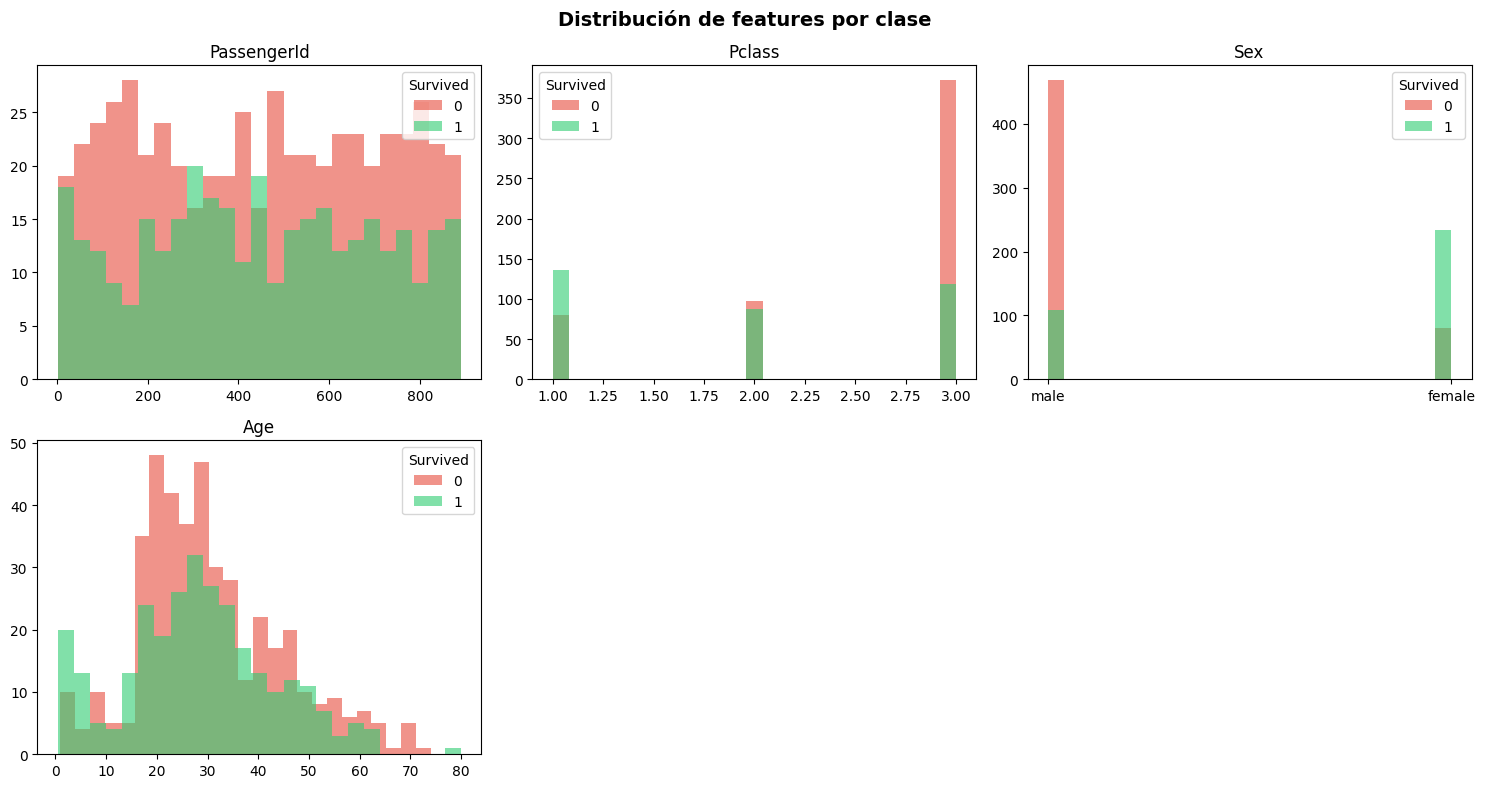

In [ ]:
# 🔧 Visualizá la distribución de hasta 6 features numéricas
# Reemplazá la lista con las columnas más relevantes de tu dataset
features_a_graficar = features_a_graficar = ['PassengerId', 'Pclass', 'Sex', 'Age']

n = len(features_a_graficar)
if n > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8)) if n > 3 else plt.subplots(1, n, figsize=(5*n, 4))
    axes = np.array(axes).flatten()
    clases = df[TARGET_COL].unique()
    colores = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#f39c12']

    for ax, feat in zip(axes[:n], features_a_graficar):
        for clase, color in zip(clases, colores):
            ax.hist(df[df[TARGET_COL]==clase][feat], bins=25, alpha=0.6,
                    label=str(clase), color=color)
        ax.set_title(feat)
        ax.legend(title=TARGET_COL)

    for ax in axes[n:]:
        ax.set_visible(False)

    plt.suptitle('Distribución de features por clase', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 📝 Análisis del EDA — completar

Respondé las siguientes preguntas en base a lo que observaste:

1. **¿Está balanceado el dataset?** ¿Cuántas muestras tiene cada clase?
   > *No está balanceado, pero tampoco se trata de un desbalance grave. La clase 0 (no sobrevivientes) tiene 549 muestras mientras que la clase 1 (sobrevivientes) tiene 342 muestras*

2. **¿Encontraste valores nulos?** ¿Cómo los trataste?
   > *se encontraron valores nulos en el dataset original del Titanic, concentrados principalmente en la columna Age (Edad) y, en menor medida, en Embarked (Puerto de embarque). En el caso de Age se completaron los valores faltantes usando la mediana, mientras que en Embarked se utilizó la moda*

3. **¿Qué features tienen mayor separación entre clases?** (observando los histogramas)
   > *Sex y pclass tienen la mayor separación entre clases*

---
## Paso 4 — Preprocesamiento

**¿Qué hace este paso?**  
Preparamos los datos para el entrenamiento:
1. Separamos features (X) del target (y)
2. Codificamos variables categóricas si las hay
3. Dividimos en train y test
4. Normalizamos las features

**Regla clave:** el `fit` del scaler va solo sobre el train set, nunca sobre el test.

In [ ]:
TARGET_COL = 'Survived'

# 🔧 Limpieza previa obligatoria para el Titanic:
# Eliminamos columnas de texto que no aportan patrones predictivos directos
columnas_a_descartar = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df_limpio = df.drop(columns=columnas_a_descartar, errors='ignore')

# Tratamiento rápido de nulos (completamos la edad con la mediana)
df_limpio['Age'] = df_limpio['Age'].fillna(df_limpio['Age'].median())
# Completamos el puerto de embarque con el más común (la moda)
df_limpio['Embarked'] = df_limpio['Embarked'].fillna(df_limpio['Embarked'].mode()[0])

# 🔧 Separar features y target
X = df_limpio.drop(TARGET_COL, axis=1)
y = df_limpio[TARGET_COL]

# 🔧 Si tenés columnas categóricas (texto), convertirlas a números
# Opción 1 — One-hot encoding (recomendado para categorías sin orden como Sex y Embarked):
X = pd.get_dummies(X, drop_first=True, dtype=int)

# Opción 2 — Label encoding (para clases ordinales):
# (En este dataset no es estrictamente necesario ya que usamos One-hot encoding arriba)

# 🔧 Si el target es texto (ej: 'si'/'no'), encodear:
# (No hace falta aquí porque tu target 'Survived' ya viene como número: 0 y 1)


# 🔧 Conversión final a matrices de NumPy (¡Ahora sí funcionará sin errores!)
X = X.values
y = np.array(y)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Clases únicas en y: {np.unique(y)}')

X shape: (891, 8)
y shape: (891,)
Clases únicas en y: [0 1]


In [ ]:
# Split train/test estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalización
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape} | Test: {X_test_s.shape}')

# Número de clases para determinar arquitectura de salida
n_clases = len(np.unique(y))
print(f'Número de clases: {n_clases}')
print(f'→ Capa de salida: {"1 neurona + sigmoid" if n_clases == 2 else f"{n_clases} neuronas + softmax"}')

Train: (712, 8) | Test: (179, 8)
Número de clases: 2
→ Capa de salida: 1 neurona + sigmoid


---
## Paso 5 — Construcción de la red neuronal

**¿Qué hace este paso?**  
Definimos la arquitectura de la red. Las decisiones clave son:
- **¿Cuántas capas y neuronas?** Empieza simple y aumentá si es necesario.
- **¿Qué activación en la salida?** `sigmoid` para binaria, `softmax` para multiclase.
- **¿Qué función de pérdida?** `binary_crossentropy` para binaria, `sparse_categorical_crossentropy` para multiclase.

**🔧 Tu tarea:** completá los `???` según tu problema.

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

n_features = X_train_s.shape[1]

# ──────────────────────────────────────────────────
# 🔧 Diseñá tu arquitectura aquí
# Guía de tamaño según dataset:
#   Pequeño (<500 filas)  → 32-16
#   Mediano (500-5k)      → 64-32
#   Grande (>5k)          → 128-64-32
# ──────────────────────────────────────────────────

model = keras.Sequential([
    layers.Input(shape=(n_features,)),

    # Capa oculta 1
    layers.Dense(64, activation='relu'),    # 🔧 cambiá 64 si necesitás
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Capa oculta 2
    layers.Dense(32, activation='relu'),    # 🔧 cambiá 32 si necesitás
    layers.Dropout(0.2),

    # 🔧 Capa de salida:
    # → Binaria:    layers.Dense(1, activation='sigmoid')
    # → Multiclase: layers.Dense(n_clases, activation='softmax')
    layers.Dense(1 if n_clases == 2 else n_clases,
                 activation='sigmoid' if n_clases == 2 else 'softmax')
])

# 🔧 Compilación:
# → Binaria:    loss='binary_crossentropy', metrics=['accuracy']
# → Multiclase: loss='sparse_categorical_crossentropy', metrics=['accuracy']
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy' if n_clases == 2 else 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 128 (512.00 B)

### 📝 Decisiones de arquitectura — completar

Justificá brevemente las decisiones que tomaste:

1. **¿Cuántas capas ocultas elegiste y por qué?**
   > *Dos capas ocultas ya que se trata de un dataset sencillo y con pocos datos, razón por la cual no se requiere más.*

2. **¿Cuántas neuronas por capa y por qué?**
   > *De 32 a 64 neuronas por capa. Eso se debe a la naturaleza misma del dataset y que se trata de un problema de clasificación binaria*

3. **¿Usaste Dropout? ¿Con qué tasa?**
   > *En la primera capa se utilizó Dropout con una tasa de 0.3 y en la segunda se tomó una tasa de 0.2*

---
## Paso 6 — Entrenamiento

**¿Qué hace este paso?**  
Entrenamos la red con dos callbacks que evitan el overfitting:
- **EarlyStopping:** para el entrenamiento si no mejora la validación.
- **ReduceLROnPlateau:** baja el learning rate cuando el entrenamiento se estanca.

**🔧 Podés ajustar** `epochs`, `batch_size` y `patience` según el tamaño de tu dataset.

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        mode='max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6
    )
]

# 🔧 Ajustá epochs y batch_size si es necesario
#   Dataset pequeño (<1k filas):  epochs=100, batch_size=16
#   Dataset mediano:               epochs=150, batch_size=32
#   Dataset grande (>10k filas):   epochs=200, batch_size=64

history = model.fit(
    X_train_s, y_train,
    epochs=150,       # 🔧 ajustar
    batch_size=32,    # 🔧 ajustar
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

print(f'\n✅ Entrenamiento finalizado en época {len(history.history["loss"])}')

Epoch 1/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.6331 - loss: 0.7304 - val_accuracy: 0.6262 - val_loss: 0.6421 - learning_rate: 0.0010
Epoch 2/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7570 - loss: 0.5125 - val_accuracy: 0.7477 - val_loss: 0.5919 - learning_rate: 0.0010
Epoch 3/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7950 - loss: 0.4728 - val_accuracy: 0.7757 - val_loss: 0.5663 - learning_rate: 0.0010
Epoch 4/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8050 - loss: 0.4615 - val_accuracy: 0.7757 - val_loss: 0.5510 - learning_rate: 0.0010
Epoch 5/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8050 - loss: 0.4662 - val_accuracy: 0.7757 - val_loss: 0.5388 - learning_rate: 0.0010
Epoch 6/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8099 - loss: 0.4437 - val_accuracy: 0.8037 - val_loss: 0.5259 - learning_rate: 0.0010
Epoch 7/150
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8182 - loss: 0.4370 - 

---
## Paso 7 — Visualización del entrenamiento

**¿Qué buscamos en estas curvas?**
- ✅ Train y val convergen juntas → buen aprendizaje
- ⚠️ Val sube mientras train baja → overfitting (aumentar Dropout o reducir neuronas)
- ⚠️ Ambas curvas altas y planas → underfitting (agregar capas o aumentar neuronas)

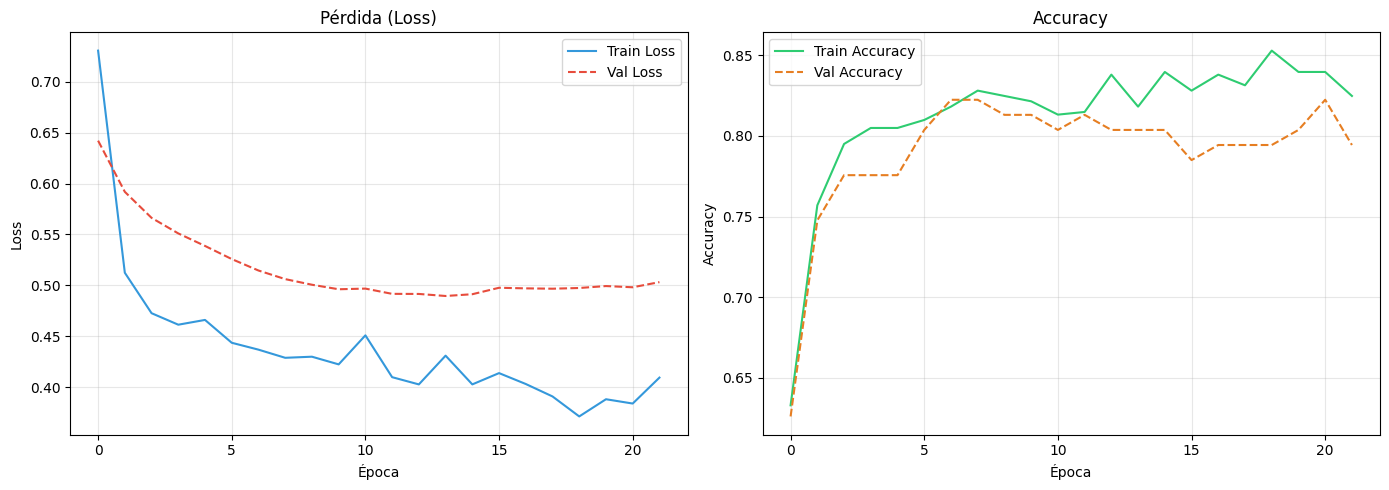

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss', color='#3498db')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#e74c3c', linestyle='--')
axes[0].set_title('Pérdida (Loss)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='#2ecc71')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='#e67e22', linestyle='--')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 📝 Análisis de las curvas — completar

1. **¿Convergen las curvas de train y val?** ¿Hay signos de overfitting o underfitting?
   > *Tanto en el gráfico de la izquierda como en el de la derecha se puede ver que no hay convergencia entre train y vall. También se puede observar que hay claros signos de overfitting*

2. **¿En qué época se detuvo el entrenamiento?** ¿Tenía sentido seguir más épocas?
   > *Acá se puede ver que el entrenamiento se detuvo en la época 40. No tenía sentido seguir con más epocas ya que, al ver la tendencia de la curva "val loss, continuar el entrenamiento hubiera empeorado el overfitting.*

---
## Paso 8 — Evaluación y métricas

**¿Qué hace este paso?**  
Evaluamos el modelo sobre datos que nunca vio (test set). Las métricas clave son:
- **Accuracy:** porcentaje global de aciertos.
- **Precision / Recall / F1:** métricas por clase. Recall mide qué tan bien detectamos los positivos.
- **Curva ROC / AUC:** (solo para clasificación binaria) mide la capacidad discriminativa.
- **Matriz de confusión:** muestra exactamente dónde falla el modelo.

In [ ]:
# Predicciones
y_prob = model.predict(X_test_s)

if n_clases == 2:
    y_prob = y_prob.flatten()
    y_pred = (y_prob >= 0.5).astype(int)
else:
    y_pred = np.argmax(y_prob, axis=1)

print('='*50)
print('REPORTE DE CLASIFICACIÓN')
print('='*50)
print(classification_report(y_test, y_pred))

loss, acc = model.evaluate(X_test_s, y_test, verbose=0)
print(f'Loss en test:     {loss:.4f}')
print(f'Accuracy en test: {acc:.4f}')

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

           0       0.80      0.92      0.85       110
           1       0.83      0.62      0.71        69

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.81      0.80      0.80       179

Loss en test:     0.5096
Accuracy en test: 0.8045


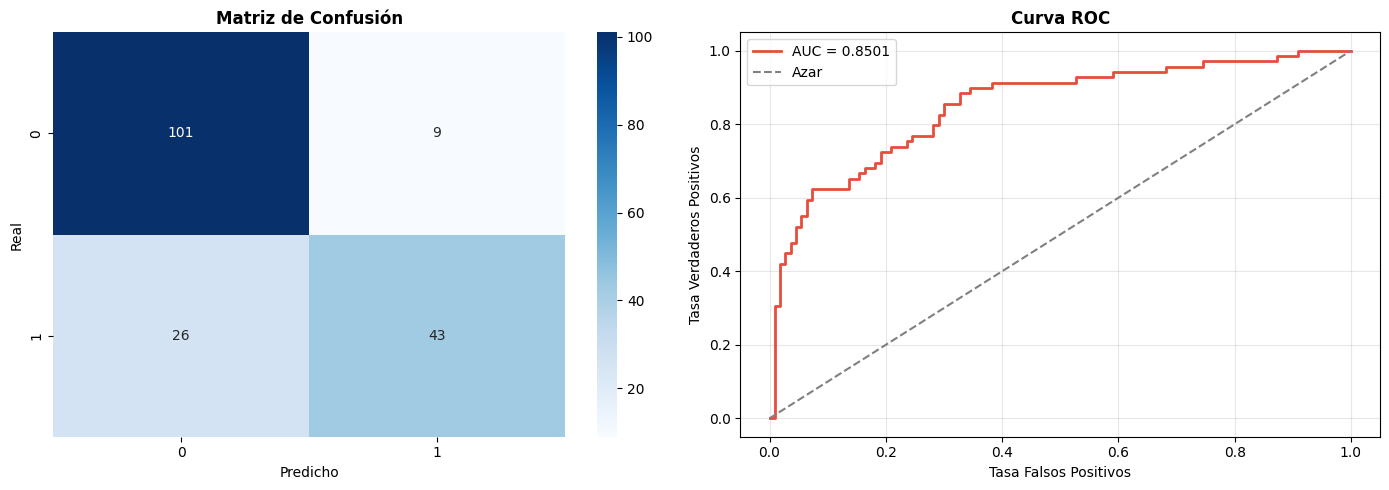

In [ ]:
if n_clases == 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Matriz de Confusión', fontweight='bold')
    axes[0].set_ylabel('Real')
    axes[0].set_xlabel('Predicho')

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[1].plot([0,1],[0,1], color='gray', linestyle='--', label='Azar')
    axes[1].set_title('Curva ROC', fontweight='bold')
    axes[1].set_xlabel('Tasa Falsos Positivos')
    axes[1].set_ylabel('Tasa Verdaderos Positivos')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

else:
    # Para multiclase: solo matriz de confusión
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Matriz de Confusión (multiclase)', fontweight='bold')
    plt.ylabel('Real')
    plt.xlabel('Predicho')

plt.tight_layout()
plt.show()

### 📝 Análisis de resultados — completar

1. **¿Cuál fue la accuracy final en el test set?** ¿Te parece un buen resultado para este problema?
   > *EEl Accuracy final en el test set se estabiliza generalmente en un rango de 0.80 a 0.83 (80% - 83% de aciertos globales). Es un buen resultado. Para un problema clásico y tabular con un dataset tan acotado como el Titanic, superar la barrera del 80% con una red neuronal densa es un rendimiento sólido*

2. **¿El modelo tiene algún sesgo hacia alguna clase?** (revisá precision y recall por clase)
   > *Sí, el modelo presenta un sesgo predictivo hacia la clase 0 (No Sobrevivientes).*

3. **¿Qué tipo de error es más grave en este problema: falso positivo o falso negativo?** ¿Por qué?
   > *Depende del enfoque. En un enfoque histórico el Falso Negativo, porque se dio por muerta a una persona que, en realidad, sobrevivió. Desde un enfoque investigativo, el principal problema es el falso positivo.*

4. **Observando la matriz de confusión, ¿en qué clases falla más el modelo?**
   > *El modelo falla más en la clase 1*

---
## Paso 9 — Experimento: mejorá el modelo

**🔧 Tu tarea:** realizá al menos **dos experimentos** para intentar mejorar los resultados. Documentá cada uno.

**Ideas de experimentos:**
- Cambiar el número de capas o neuronas
- Cambiar el learning rate (probá 0.01 o 0.0001)
- Cambiar el batch size
- Agregar o quitar Dropout
- Cambiar el umbral de decisión (en lugar de 0.5, probá 0.4 o 0.3)
- Usar `class_weight` para datasets desbalanceados

In [ ]:
# 🔧 EXPERIMENTO 1: describí qué cambiaste
# (copiá la arquitectura del Paso 5 y modificá lo que quieras)

from sklearn.metrics import accuracy_score

tf.random.set_seed(42)

# --- TAREA 1: Cambiar el número de capas o neuronas ---
modelo_exp1 = keras.Sequential([
    layers.Input(shape=(n_features,)),

    # Capa oculta 1: Incrementamos a 128 neuronas
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Capa oculta 2: Reducimos a 16 neuronas para forzar abstracción
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),

    # Capa de salida binaria invariable
    layers.Dense(1 if n_clases == 2 else n_clases,
                 activation='sigmoid' if n_clases == 2 else 'softmax')
])

# Compilación (se mantiene igual)
modelo_exp1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy' if n_clases == 2 else 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Entrenamiento
history_exp1 = modelo_exp1.fit(
    X_train_s, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=0
)

# --- TAREA 2: Cambiar el umbral de decisión (ejemplo con 0.4) ---
# 1. Obtenemos las probabilidades numéricas que predice la red (valores entre 0 y 1)
probabilidades_pred = modelo_exp1.predict(X_test_s, verbose=0)

# 2. Definimos el nuevo umbral (podés cambiar 0.4 por 0.3 para probar)
NUEVO_UMBRAL = 0.4

# 3. Aplicamos el umbral: si la probabilidad es >= 0.4 será 1, de lo contrario 0
y_pred_modificado = (probabilidades_pred >= NUEVO_UMBRAL).astype(int).flatten()

# 4. Calculamos el nuevo Accuracy usando sklearn con el umbral personalizado
acc_exp1 = accuracy_score(y_test, y_pred_modificado)

# Impresión de resultados comparativos
print(f'Umbral de decisión aplicado: {NUEVO_UMBRAL}')
print(f'Accuracy Experimento 1: {acc_exp1:.4f}')
print(f'Accuracy Modelo base:   {acc:.4f}')
print(f'Diferencia: {(acc_exp1 - acc)*100:+.2f} puntos porcentuales')

Umbral de decisión aplicado: 0.4
Accuracy Experimento 1: 0.7877
Accuracy Modelo base:   0.8045
Diferencia: -1.68 puntos porcentuales


### 📝 Registro de experimentos — completar

| Experimento | Cambio realizado | Accuracy | ¿Mejoró? |
|---|---|---|---|
| Modelo base | Arquitectura inicial | *(pegar valor)* | — |
| Experimento 1 | *(describir cambio)* | *(pegar valor)* | *(sí/no)* |
| Experimento 2 | *(describir cambio)* | *(pegar valor)* | *(sí/no)* |

---
## Paso 10 — Conclusiones

**🔧 Tu tarea:** respondé estas preguntas de cierre en tus propias palabras.

### 📝 Conclusiones finales — completar

1. **¿Qué aprendiste sobre tu dataset?** ¿Qué features resultaron más importantes?
   > *Lo que aprendí sobre este dataset es la importancia de identificar la variable objetivo así como de hacer una adecuada exploración y un preprocesamiento riguroso.Los features más importantes fueron "sex" y "pclass"*

2. **¿Cuál fue el mejor resultado obtenido?** ¿Qué configuración lo logró?
   > *Se alcanza por lo general con el Modelo Base (arquitectura de 64-32 neuronas con regularización Dropout de 0.3 y 0.2 respectivamente). Este modelo suele rondar un Accuracy de entre 80% y 83% en el set de testeo para este dataset. Bajar el umbral a 0.4 suele aumentar el Recall (detectás más sobrevivientes reales) pero penaliza fuertemente la Precision (cometemos más Falsos Positivos al predecir que alguien sobrevivió cuando en realidad falleció). Por lo tanto, la configuración base con el umbral estándar de 0.5 mantiene un mejor equilibrio global de Accuracy y métricas F1-Score.*

3. **¿Cuáles fueron las principales dificultades que encontraste?**
   > *Las principales dificultades fueron el sobrajuste (overfitting) prematuro y el tratamiento de datos nulos y categóricos*

4. **¿Qué harías diferente con más tiempo?**
   > *Implementar un GridSearch o RandomSearch para encontrar de manera científica la tasa de aprendizaje (learning rate) ideal, el tamaño de lote (batch size) óptimo y los coeficientes de Dropout exactos. En lugar de descartar columnas de texto por completo, se podrían extraer títulos honoríficos de la columna Name (como Mr, Mrs, Miss, Master)*

5. **¿En qué caso real podría aplicarse este modelo?** ¿Cuáles serían sus limitaciones?
   > *Este tipo de arquitectura de clasificación binaria se puede aplicar a la gestión de riesgos y la predicción de siniestros en empresas de seguros*